# SeQUeNCe Tutorial
## Quantum Network Simulation for Optimal Routing (Caleffi 2017)

SeQUeNCe (**S**imulator of **QU**antum **N**etwork **C**ommunication and **E**ngineering) is a Python-based, discrete-event simulator for quantum networks. It models the actual physical hardware — memories, photons, channels, Bell-state measurements — rather than abstract qubits.

### Why SeQUeNCe for this paper?
Caleffi (2017) models a quantum network of **cavity-based repeaters** that:
- Generate atom-photon entanglement locally
- Create remote entanglement via photon-photon Bell-state measurement (BSM)
- Extend entanglement to non-adjacent nodes via entanglement swapping
- Are affected by decoherence, photon loss, and imperfect BSM

SeQUeNCe directly simulates all of these mechanisms.

---

### Core Concepts

| Concept | Class | Role |
|---------|-------|------|
| **Timeline** | `Timeline` | The discrete-event engine. Holds all events and advances simulated time. |
| **Quantum Router** | `QuantumRouter` | A node with quantum memories, resource manager, and network manager. |
| **BSM Node** | `BSMNode` | An intermediate node that performs Bell-state measurements on photons from two routers. |
| **Quantum Channel** | `QuantumChannel` | An optical fiber transmitting photons (with attenuation and loss). |
| **Classical Channel** | `ClassicalChannel` | A classical communication link (with propagation delay). |
| **Memory** | `Memory` | A quantum memory (atom) storing a qubit, subject to decoherence. |
| **Application** | `RequestApp` | The application layer: requests entanglement between two nodes. |

### Time unit
All times in SeQUeNCe are in **picoseconds (ps)**.
- 1 second = `1e12` ps
- 1 millisecond = `1e9` ps


---
## Part 1 — Architecture: How a Simulation is Structured

```
         ┌─────────┐     QuantumChannel     ┌──────────┐     QuantumChannel     ┌─────────┐
         │   r1    │ ─────────────────────> │  BSM_12  │ <───────────────────── │   r2    │
         │ (router)│                        │ (bsm node│                        │ (router)│
         └─────────┘ <──────────────────────┤          │──────────────────────> └─────────┘
                           ClassicalChannel └──────────┘      ClassicalChannel
```

**Each link between two routers requires:**
1. A `BSMNode` placed in the middle of the fiber
2. Two `QuantumChannel`s: one from each router to the BSM node
3. `ClassicalChannel`s in both directions between all pairs of nodes (for signaling)

SeQUeNCe handles this automatically when you use the `qconnections` config key with `"type": "meet_in_the_middle"`.

**Entanglement generation sequence:**
1. Both routers excite their atoms, emitting photons into the fiber toward the BSM node
2. The BSM node performs a Bell-state measurement on the two arriving photons
3. If the BSM succeeds, both routers are notified via classical channel — their atoms are now entangled
4. For multi-hop: entanglement swapping at intermediate routers extends the entanglement end-to-end


---
## Part 2 — Imports and Verification

In [1]:
import json
import tempfile
import os
import matplotlib.pyplot as plt

# Core simulation engine
from sequence.kernel.timeline import Timeline

# Node types
from sequence.topology.node import QuantumRouter, BSMNode

# Topology loader (reads JSON config files)
from sequence.topology.router_net_topo import RouterNetTopo

# Application layer: requests entanglement between two routers
from sequence.app.request_app import RequestApp

# Channels
from sequence.components.optical_channel import QuantumChannel, ClassicalChannel

print("SeQUeNCe imported successfully")

SeQUeNCe imported successfully


---
## Part 3 — Simulation 1: Direct Link (2 Routers)

The simplest possible network: two quantum routers connected by a single fiber link.

```
  r1 ─────────── BSM_r1_r2 ─────────── r2
       25 km fiber         25 km fiber
       (total link: 50 km)
```

We will:
1. Define the network in a JSON config
2. Run the simulation
3. Measure the entanglement throughput


### 3.1 — The JSON Configuration

SeQUeNCe uses a JSON file to describe the network. The key sections are:

- **`stop_time`**: when the simulation ends (in ps)
- **`nodes`**: list of `QuantumRouter` nodes with their parameters
- **`qconnections`**: quantum links between routers (BSM node is auto-created in the middle)
- **`cconnections`**: classical links (needed for signaling, reservation, and BSM result delivery)
- **`templates`** *(optional)*: reusable hardware parameter presets


In [2]:
# Helper: write config to a temp file and return the path
def write_config(config: dict) -> str:
    f = tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False)
    json.dump(config, f)
    f.close()
    return f.name


# ── Network configuration ────────────────────────────────────────────
SIM_DURATION_S  = 10          # seconds
SIM_DURATION_PS = int(SIM_DURATION_S * 1e12)   # convert to picoseconds

LINK_DISTANCE_M = 50_000      # 50 km total fiber length (meters)
ATTENUATION     = 0.0002      # fiber attenuation: loss per meter (≈ 0.1 dB/km)
CC_DELAY_PS     = int(250e9)  # classical channel delay: 250 ms in ps

config_2node = {
    "stop_time":   SIM_DURATION_PS,
    "is_parallel": False,          # required by some SeQUeNCe versions

    # Hardware template: realistic cavity-based memory parameters
    "templates": {
        "cavity_memory": {
            "MemoryArray": {
                "fidelity":       0.95,   # initial state fidelity
                "efficiency":     0.75,   # probability of successfully emitting a photon
                "coherence_time": 30,     # memory lifetime in seconds (decoherence time T)
                "frequency":      2e3     # max excitation rate in Hz
            }
        }
    },

    "nodes": [
        {"name": "r1", "type": "QuantumRouter", "seed": 0, "memo_size": 10,
         "template": "cavity_memory"},
        {"name": "r2", "type": "QuantumRouter", "seed": 1, "memo_size": 10,
         "template": "cavity_memory"}
    ],

    # qconnections: quantum links.
    # 'meet_in_the_middle' places a BSMNode at the midpoint of the fiber.
    # SeQUeNCe auto-creates the BSM node and both quantum channels.
    "qconnections": [
        {
            "node1":       "r1",
            "node2":       "r2",
            "attenuation": ATTENUATION,
            "distance":    LINK_DISTANCE_M,
            "type":        "meet_in_the_middle",
            "seed":        2
        }
    ],

    # cconnections: bidirectional classical links.
    # One entry creates two channels (r1->r2 and r2->r1).
    "cconnections": [
        {"node1": "r1", "node2": "r2", "delay": CC_DELAY_PS}
    ]
}

print(json.dumps(config_2node, indent=2))

{
  "stop_time": 10000000000000,
  "is_parallel": false,
  "templates": {
    "cavity_memory": {
      "MemoryArray": {
        "fidelity": 0.95,
        "efficiency": 0.75,
        "coherence_time": 30,
        "frequency": 2000.0
      }
    }
  },
  "nodes": [
    {
      "name": "r1",
      "type": "QuantumRouter",
      "seed": 0,
      "memo_size": 10,
      "template": "cavity_memory"
    },
    {
      "name": "r2",
      "type": "QuantumRouter",
      "seed": 1,
      "memo_size": 10,
      "template": "cavity_memory"
    }
  ],
  "qconnections": [
    {
      "node1": "r1",
      "node2": "r2",
      "attenuation": 0.0002,
      "distance": 50000,
      "type": "meet_in_the_middle",
      "seed": 2
    }
  ],
  "cconnections": [
    {
      "node1": "r1",
      "node2": "r2",
      "delay": 250000000000
    }
  ]
}


### 3.2 — Run the Simulation

In [3]:
def run_simulation(config: dict, initiator: str, responder: str,
                   memo_size: int = 5, fidelity: float = 0.8,
                   warmup_s: float = 1.0) -> dict:
    """
    Run a SeQUeNCe entanglement distribution simulation.

    Args:
        config:     Network configuration dictionary.
        initiator:  Name of the requesting router.
        responder:  Name of the target router.
        memo_size:  Number of memory slots requested for this session.
        fidelity:   Minimum acceptable fidelity for entangled pairs.
        warmup_s:   Seconds to wait before starting the request
                    (allows the network to initialize).

    Returns:
        dict with 'entanglements' count and 'throughput' in pairs/s.
    """
    stop_time = config["stop_time"]
    start_t   = int(warmup_s * 1e12)
    end_t     = stop_time - int(0.5e12)   # end slightly before sim stop

    cfg_file = write_config(config)
    try:
        topo = RouterNetTopo(cfg_file)
        tl   = topo.tl

        node = tl.get_entity_by_name(initiator)
        app  = RequestApp(node)
        node.set_app(app)

        tl.init()
        app.start(responder, start_t, end_t, memo_size, fidelity)
        tl.run()

        return {
            "entanglements": app.memory_counter,
            "throughput":    app.get_throughput()
        }
    finally:
        os.unlink(cfg_file)


# Run the 2-node simulation
result = run_simulation(config_2node, "r1", "r2")

print(f"Entanglement pairs generated : {result['entanglements']}")
print(f"Throughput                   : {result['throughput']:.4f} pairs/s")

Entanglement pairs generated : 2
Throughput                   : 0.2353 pairs/s


### 3.3 — What happened inside SeQUeNCe?

When `tl.run()` executes, SeQUeNCe processes discrete events in time order:

1. **`RequestApp.start()`** calls `r1.reserve_net_resource()`, which sends a reservation message through the network (RSVP protocol)
2. **Each router** along the path accepts the reservation and allocates memory slots
3. **Resource manager** generates rules: entanglement generation protocols are scheduled on the allocated memories
4. **Entanglement generation**: r1 and r2 each emit photons toward the BSM node. The BSM node performs the Bell-state measurement.
5. **If BSM succeeds**: both routers are notified via classical channel — their atoms are now entangled (stored in memory)
6. **`RequestApp.get_memory()`** is called when an entangled pair arrives at r1. It checks fidelity and increments the counter.
7. Steps 4–6 repeat for the duration of the reservation window.


---
## Part 4 — Key Physical Parameters

This section shows how each hardware parameter affects the entanglement rate — which is the central quantity in Caleffi's paper.

### 4.1 — Effect of Fiber Distance

Longer fiber = more photon loss = fewer successful BSM events = lower entanglement rate.
This is the exponential decay with distance that Caleffi discusses in Section I.

   10 km  →  0.3529 pairs/s
   20 km  →  0.2353 pairs/s
   30 km  →  0.2353 pairs/s
   40 km  →  0.3529 pairs/s
   50 km  →  0.2353 pairs/s
   60 km  →  0.1176 pairs/s
   70 km  →  0.1176 pairs/s


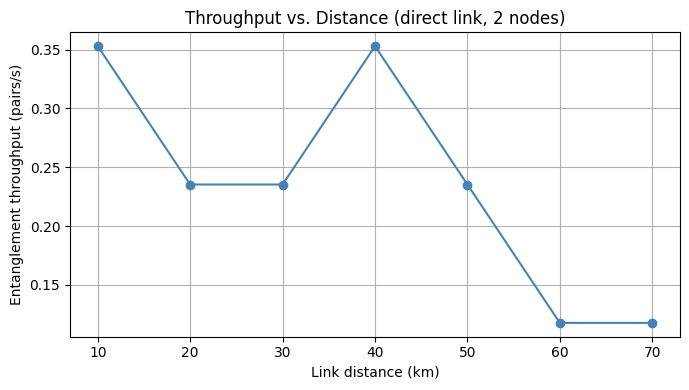

In [4]:
import copy

distances_km = [10, 20, 30, 40, 50, 60, 70]
throughputs   = []

for d_km in distances_km:
    cfg = copy.deepcopy(config_2node)
    cfg["qconnections"][0]["distance"] = d_km * 1000   # meters
    res = run_simulation(cfg, "r1", "r2", memo_size=5, fidelity=0.5)
    throughputs.append(res["throughput"])
    print(f"  {d_km:3d} km  →  {res['throughput']:.4f} pairs/s")

plt.figure(figsize=(7, 4))
plt.plot(distances_km, throughputs, 'o-', color='steelblue')
plt.xlabel("Link distance (km)")
plt.ylabel("Entanglement throughput (pairs/s)")
plt.title("Throughput vs. Distance (direct link, 2 nodes)")
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.2 — Effect of Memory Coherence Time

In Caleffi's model, the **decoherence time** $T^c$ is a central parameter. A longer coherence time means the entanglement stored in the atom survives long enough to be used for swapping. This matters especially for multi-hop paths where you need to hold the state while waiting for neighboring links to succeed.

  coherence_time =   0.5 s  →  0.0000 pairs/s
  coherence_time =   1.0 s  →  0.1176 pairs/s
  coherence_time =   5.0 s  →  0.1176 pairs/s
  coherence_time =  10.0 s  →  0.2353 pairs/s
  coherence_time =  30.0 s  →  0.2353 pairs/s
  coherence_time =  60.0 s  →  0.2353 pairs/s


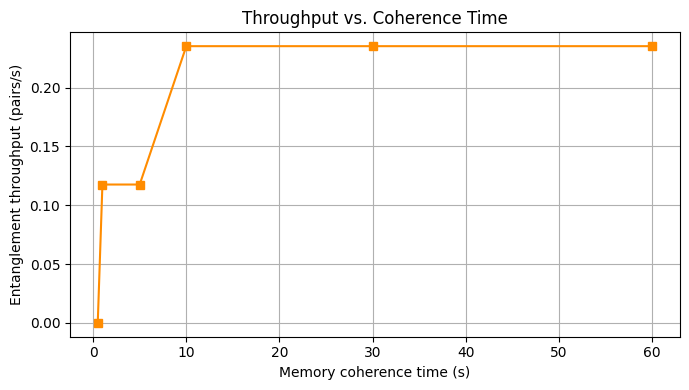

In [5]:
coherence_times_s = [0.5, 1, 5, 10, 30, 60]
throughputs_coh   = []

for ct in coherence_times_s:
    cfg = copy.deepcopy(config_2node)
    cfg["templates"]["cavity_memory"]["MemoryArray"]["coherence_time"] = ct
    res = run_simulation(cfg, "r1", "r2", memo_size=5, fidelity=0.5)
    throughputs_coh.append(res["throughput"])
    print(f"  coherence_time = {ct:5.1f} s  →  {res['throughput']:.4f} pairs/s")

plt.figure(figsize=(7, 4))
plt.plot(coherence_times_s, throughputs_coh, 's-', color='darkorange')
plt.xlabel("Memory coherence time (s)")
plt.ylabel("Entanglement throughput (pairs/s)")
plt.title("Throughput vs. Coherence Time")
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.3 — Effect of Memory Efficiency

**Memory efficiency** (η) is the probability that exciting an atom actually produces a photon. This maps to the atom-photon entanglement generation probability in Caleffi's model.
Lower efficiency = fewer photons reaching the BSM node = fewer successful BSM events.

  efficiency = 0.20  →  0.0000 pairs/s
  efficiency = 0.40  →  0.1176 pairs/s
  efficiency = 0.60  →  0.1176 pairs/s
  efficiency = 0.75  →  0.2353 pairs/s
  efficiency = 0.90  →  0.3529 pairs/s
  efficiency = 1.00  →  0.3529 pairs/s


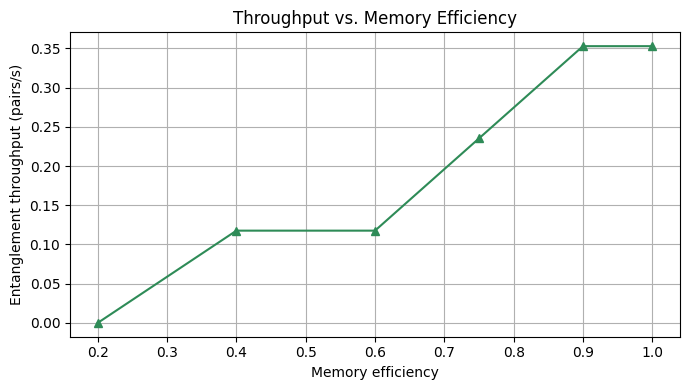

In [6]:
efficiencies    = [0.2, 0.4, 0.6, 0.75, 0.9, 1.0]
throughputs_eff = []

for eff in efficiencies:
    cfg = copy.deepcopy(config_2node)
    cfg["templates"]["cavity_memory"]["MemoryArray"]["efficiency"] = eff
    res = run_simulation(cfg, "r1", "r2", memo_size=5, fidelity=0.5)
    throughputs_eff.append(res["throughput"])
    print(f"  efficiency = {eff:.2f}  →  {res['throughput']:.4f} pairs/s")

plt.figure(figsize=(7, 4))
plt.plot(efficiencies, throughputs_eff, '^-', color='seagreen')
plt.xlabel("Memory efficiency")
plt.ylabel("Entanglement throughput (pairs/s)")
plt.title("Throughput vs. Memory Efficiency")
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Part 5 — Simulation 2: Multi-Hop (3 Routers, Entanglement Swapping)

This is the core of Caleffi's paper: distributing entanglement over multiple hops via **entanglement swapping** at intermediate nodes.

```
  r1 ──── BSM_12 ──── r2 ──── BSM_23 ──── r3
     20 km         20 km
```

What happens:
1. r1↔r2 become entangled (link 1)
2. r2↔r3 become entangled (link 2)
3. r2 performs an **atomic BSM** on its two memory qubits → r1 and r3 become entangled end-to-end
4. r2 sends classical correction bits to r1 and r3

> **Note:** Classical channels must connect ALL pairs of routers (including r1↔r3), because swapping correction messages need to flow directly.

In [7]:
config_3node = {
    "stop_time": int(100e12),   # 100 seconds
    "is_parallel": False,

    "templates": {
        "cavity_memory": {
            "MemoryArray": {
                "fidelity":       0.95,
                "efficiency":     0.75,
                "coherence_time": 30,
                "frequency":      2e3
            }
        }
    },

    "nodes": [
        {"name": "r1", "type": "QuantumRouter", "seed": 0, "memo_size": 20, "template": "cavity_memory"},
        {"name": "r2", "type": "QuantumRouter", "seed": 1, "memo_size": 20, "template": "cavity_memory"},
        {"name": "r3", "type": "QuantumRouter", "seed": 2, "memo_size": 20, "template": "cavity_memory"}
    ],

    "qconnections": [
        {"node1": "r1", "node2": "r2", "attenuation": 0.0002, "distance": 20_000,
         "type": "meet_in_the_middle", "seed": 3},
        {"node1": "r2", "node2": "r3", "attenuation": 0.0002, "distance": 20_000,
         "type": "meet_in_the_middle", "seed": 4}
    ],

    # IMPORTANT: include a classical channel for every pair of routers,
    # even non-adjacent ones (r1 <-> r3), for swapping correction messages.
    "cconnections": [
        {"node1": "r1", "node2": "r2", "delay": int(100e9)},
        {"node1": "r2", "node2": "r3", "delay": int(100e9)},
        {"node1": "r1", "node2": "r3", "delay": int(200e9)}
    ]
}

result_3node = run_simulation(
    config_3node, "r1", "r3",
    memo_size=10, fidelity=0.5, warmup_s=1.0
)

print(f"Entanglement pairs generated : {result_3node['entanglements']}")
print(f"Throughput                   : {result_3node['throughput']:.4f} pairs/s")

Entanglement pairs generated : 40
Throughput                   : 0.4061 pairs/s


### 5.1 — Compare Direct Link vs Multi-Hop

For the same total distance (40 km), compare two architectures:
- **Direct**: r1 → BSM → r2 over 40 km
- **Two-hop**: r1 → BSM → r2 → BSM → r3, each hop 20 km

This is exactly the question Caleffi asks in Section I: *"when does a repeater assure higher entanglement distribution over the direct long link?"*

Total distance: 40 km
  Direct link (40 km)  : 0.2132 pairs/s
  Two hops (20+20 km)  : 0.4061 pairs/s


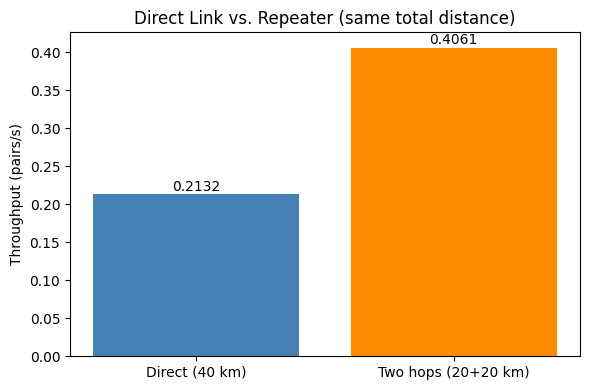

In [8]:
# Direct link: 40 km total
cfg_direct = copy.deepcopy(config_2node)
cfg_direct["stop_time"] = int(100e12)
cfg_direct["qconnections"][0]["distance"] = 40_000

res_direct = run_simulation(cfg_direct, "r1", "r2",
                             memo_size=10, fidelity=0.5, warmup_s=1.0)

# Two-hop: 20 km + 20 km
res_2hop = run_simulation(config_3node, "r1", "r3",
                           memo_size=10, fidelity=0.5, warmup_s=1.0)

print("Total distance: 40 km")
print(f"  Direct link (40 km)  : {res_direct['throughput']:.4f} pairs/s")
print(f"  Two hops (20+20 km)  : {res_2hop['throughput']:.4f} pairs/s")

labels      = ["Direct (40 km)", "Two hops (20+20 km)"]
throughputs = [res_direct["throughput"], res_2hop["throughput"]]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, throughputs, color=["steelblue", "darkorange"])
plt.ylabel("Throughput (pairs/s)")
plt.title("Direct Link vs. Repeater (same total distance)")
for bar, val in zip(bars, throughputs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

---
## Part 6 — Inspecting the Network Topology

SeQUeNCe automatically builds the forwarding table using Dijkstra's algorithm. You can inspect which next-hop each router uses.

In [9]:
cfg_file = write_config(config_3node)
topo     = RouterNetTopo(cfg_file)
tl       = topo.tl
os.unlink(cfg_file)

print("All nodes in simulation:")
for node_type, nodes in topo.get_nodes().items():
    for node in nodes:
        print(f"  [{node_type}]  {node.name}")

print()
print("Forwarding tables (next-hop routing):")
routers = topo.get_nodes_by_type(RouterNetTopo.QUANTUM_ROUTER)
for router in routers:
    table = router.network_manager.forwarding_table
    print(f"  {router.name}: {table}")

print()
print("Quantum channels:")
for qc in topo.qchannels:
    print(f"  {qc.sender.name} → {qc.receiver}  "
          f"({qc.distance/1000:.1f} km, attenuation={qc.attenuation})")

print()
print("Classical channels:")
for cc in topo.cchannels:
    print(f"  {cc.sender.name} → {cc.receiver}")

All nodes in simulation:
  [QuantumRouter]  r1
  [QuantumRouter]  r2
  [QuantumRouter]  r3
  [BSMNode]  BSM.r1.r2
  [BSMNode]  BSM.r2.r3

Forwarding tables (next-hop routing):
  r1: {'r2': 'r2', 'r3': 'r2'}
  r2: {'r1': 'r1', 'r3': 'r3'}
  r3: {'r1': 'r2', 'r2': 'r2'}

Quantum channels:
  r1 → BSM.r1.r2  (10.0 km, attenuation=0.0002)
  r2 → BSM.r1.r2  (10.0 km, attenuation=0.0002)
  r2 → BSM.r2.r3  (10.0 km, attenuation=0.0002)
  r3 → BSM.r2.r3  (10.0 km, attenuation=0.0002)

Classical channels:
  r1 → BSM.r1.r2
  BSM.r1.r2 → r1
  r2 → BSM.r1.r2
  BSM.r1.r2 → r2
  r2 → BSM.r2.r3
  BSM.r2.r3 → r2
  r3 → BSM.r2.r3
  BSM.r2.r3 → r3
  r1 → r2
  r2 → r1
  r2 → r3
  r3 → r2
  r1 → r3
  r3 → r1


---
## Part 7 — Summary

| Concept | What you configured | Caleffi's paper equivalent |
|---------|--------------------|--------------------------|
| `distance` (m) in `qconnections` | Total fiber length of link $e_{i,j}$ | $d_{i,j}$ |
| `attenuation` in `qconnections` | Photon loss per meter | Photon loss $\eta_d$ |
| `coherence_time` in memory template | How long atom holds entanglement | Decoherence time $T^c$ |
| `efficiency` in memory template | Atom-photon entanglement success prob. | $p_{ap}$ |
| `fidelity` in memory template | Initial entanglement fidelity | Fidelity parameter |
| `memo_size` | Number of parallel memory slots per node | Memory array size |
| `RequestApp.get_throughput()` | Measured entanglement rate | $R_{e2e}(r_{i,j})$ |

### Next steps for the paper implementation

1. **Reproduce Figure plots** (Section V): sweep distance and coherence time and plot the entanglement rate
2. **Implement Caleffi's routing metric**: compute the analytical closed-form rate from Eq. (X) and use it as an edge weight to select the best path
3. **Compare routing strategies**: run SeQUeNCe with different paths and verify that Caleffi's metric selects the one with highest simulated throughput
4. **Scale up**: add more nodes to build the larger topologies described in the paper
